# Welcome to Lab: GPA 🎓

In this lab, you'll explore the GPA dataset again to find out more about the courses here at UIUC!

Fun fact: the dataset you're using in this lab is the same dataset that Professor Wade uses to make the GPA visualizations! :)  Check this out here if you haven't seen it already: [https://waf.cs.illinois.edu/discovery/grade_disparity_between_sections_at_uiuc/](https://waf.cs.illinois.edu/discovery/grade_disparity_between_sections_at_uiuc/)


A few tips to remember:

- **You are not alone on your journey in learning programming!**  You have your lab TA, your CAs, your lab group, and the professors (Prof. Wade and Prof. Karle), who are all here to help you out!
- If you find yourself stuck for more than a few minutes, ask a neighbor or course staff for help!  When you are giving help to your neighbor, explain the **idea and approach** to the problem without sharing the answer itself so they can have the same **<i>ah-hah</i>** moment!
- We are here to help you!  Don't feel embarrassed or shy to ask us for help!

Let's get started!

In [3]:
# Meet your CAs and TA if you haven't already!
# ...first name is enough, we'll know who they are! :)
ta_name = "Mehmet"
ca1_name = "Bella"
ca2_name = "Jonah"
ca3_name = ""


# Say hello to each other!
# - Groups of 3 are ideal :)
# - However, groups of 2 or 4 are fine too!
#
# Question of the Day (QOTD) to Ask Your Group: "What's your favorite social media?"
partner1_name = "Neha"
partner1_netid = "nayak11"
partner1_favsocialmedia = "Instagram"

partner2_name = "Antigoni"
partner2_netid = "agarbis2"
partner2_favsocialmedia = "Instagram"

partner3_name = "Victoria"
partner3_netid = "vgazda2"
partner3_favsocialmedia= "Instagram"

# Which lab section are you in? Record it below! It should start with a Y and have 
# 2 numbers after the Y. If you're unsure - ask your TA/CAs!
lab_section = "Y05"

<hr style="color: #DD3403;">

# Part 1: Exploring GPA

## Load the GPA Dataset

Before we begin exploring the GPA Dataset, we've got to load it in! The most recent version of the "GPA Dataset" (up to Winter 2024) is available here:
```
https://waf.cs.illinois.edu/discovery/gpa.csv
```

Use Python to load this dataset into a DataFrame called `df`:

In [4]:
import pandas as pd
df=pd.read_csv("https://waf.cs.illinois.edu/discovery/gpa.csv")
df

,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,C+,C,C-,D+,D,D-,F,W,Primary Instructor,Students
0,2024,Winter,2024-wi,ADV,150,Introduction to Advertising,ONL,22,18,1,...,0,0,0,0,0,0,0,0,"Hall, Steven R",42
1,2024,Winter,2024-wi,AFRO,100,Intro to African American St,ONL,5,8,6,...,0,1,1,0,0,0,1,0,"McMillion, Desiree Y",25
2,2024,Winter,2024-wi,ASTR,330,Extraterrestrial Life,ONL,1,16,8,...,1,0,2,0,1,0,0,0,"Dunne, Bryan C",37
3,2024,Winter,2024-wi,ATMS,120,Severe and Hazardous Weather,ONL,3,16,3,...,2,2,1,1,1,1,2,0,"Choate, Jessica J",46
4,2024,Winter,2024-wi,BADM,275,Operations Management,ONL,0,49,17,...,2,3,0,0,0,0,0,0,"Hu, Junqi",81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69107,2010,Summer,2010-su,STAT,410,Statistics and Probability II,LEC,5,10,2,...,0,1,3,0,0,0,2,1,"Stepanov, Alexei G",31
69108,2010,Summer,2010-su,STAT,440,Statistical Data Management,LEC,4,12,8,...,0,0,0,0,0,0,0,0,"Unger, David",28
69109,2010,Summer,2010-su,TAM,212,Introductory Dynamics,LEC,0,1,3,...,5,1,1,0,2,0,1,0,"Morgan, William T",28
69110,2010,Summer,2010-su,TAM,251,Introductory Solid Mechanics,LCD,1,2,2,...,3,3,2,0,0,1,1,0,"Ott-Monsivais, Stephanie",21


### 🔬 Test Case Checkpoint 🔬

In [5]:
## == CHECKPOINT TEST CASES ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any errors, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
assert(len(df) == 69112), "This is not the GPA dataset you're looking for."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Puzzle 1.1: The "Average GPA" Column
Each row in the GPA Dataset represents a **course section** at Illinois. For our exploratory data analysis, we are going to need an additional `Average GPA` column.

To create this column, we need to compute the **weighted average GPA** for each course section by taking into account the **number of students** who received each letter grade and the weight of each letter grade (see page 30 of your notebook for details).  To find the grade points for each letter grade, see the [Illinois Registrar](https://registrar.illinois.edu/courses-grades/explanation-of-grades/).


Using the cell below, write a function named `calculateAverageGPA` that accepts one parameter called `row` and **always** returns the Average GPA of the row.

In [17]:
def calculateAverageGPA(row):
    grade_points = {"A+": 4.0, "A": 4.0, "A-": 3.67, "B+": 3.33, "B": 3.0, "B-": 2.67, "C+": 2.33, "C": 2.0, "C-": 1.67,"D+": 1.33, "D": 1.0, "D-": 0.67,"F": 0.0}
    total_points = 0
    total_students = 0
    for grade, points in grade_points.items():
        num_students = row[grade]
        total_points += points * num_students
        total_students += num_students
    return total_points / total_students if total_students > 0 else None


Using the cell below, create the `Average GPA` column in our DataFrame, `df`, using the `calculateAverageGPA` and `apply` functions.

(Hint): Look back to `lab_illini` part 2.2

In [18]:
df["Average GPA"] = df.apply(calculateAverageGPA, axis=1)
df


,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
0,2024,Winter,2024-wi,ADV,150,Introduction to Advertising,ONL,22,18,1,...,0,0,0,0,0,0,0,"Hall, Steven R",42,3.968333
1,2024,Winter,2024-wi,AFRO,100,Intro to African American St,ONL,5,8,6,...,1,1,0,0,0,1,0,"McMillion, Desiree Y",25,3.467600
2,2024,Winter,2024-wi,ASTR,330,Extraterrestrial Life,ONL,1,16,8,...,0,2,0,1,0,0,0,"Dunne, Bryan C",37,3.495946
3,2024,Winter,2024-wi,ATMS,120,Severe and Hazardous Weather,ONL,3,16,3,...,2,1,1,1,1,2,0,"Choate, Jessica J",46,3.108696
4,2024,Winter,2024-wi,BADM,275,Operations Management,ONL,0,49,17,...,3,0,0,0,0,0,0,"Hu, Junqi",81,3.712346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69107,2010,Summer,2010-su,STAT,410,Statistics and Probability II,LEC,5,10,2,...,1,3,0,0,0,2,1,"Stepanov, Alexei G",31,3.183226
69108,2010,Summer,2010-su,STAT,440,Statistical Data Management,LEC,4,12,8,...,0,0,0,0,0,0,0,"Unger, David",28,3.774643
69109,2010,Summer,2010-su,TAM,212,Introductory Dynamics,LEC,0,1,3,...,1,1,0,2,0,1,0,"Morgan, William T",28,2.595714
69110,2010,Summer,2010-su,TAM,251,Introductory Solid Mechanics,LCD,1,2,2,...,3,2,0,0,1,1,0,"Ott-Monsivais, Stephanie",21,2.603333


### 🔬 Test Case Checkpoint 🔬

In [19]:
## == TEST CASES for Puzzle 1.1 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
import math
assert( len(df) == 69112  ), "You shouldn't be changing the length of `df` when computing Average GPA."
assert( "Average GPA" in df.columns), "Make sure your new column is named 'Average GPA'."
assert( math.isclose(df['Average GPA'].mean(), 3.3790213685614776)), "Your calculation of the Average GPA is incorrect."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Puzzle 1.2: The "Hardest" and "Easiest" Courses?
One way to judge a course's difficulty is to consider its **Average GPA**. 

Using the `Average GPA` column you created and the two cells below, find:
- The **50** courses with the **lowest** `Average GPA`, storing in the DataFrame `df_hard`
- The **50** courses with the **highest** `Average GPA`, storing the DataFrame `df_easy` 

In [22]:
df_hard = df.nsmallest(50, "Average GPA")
df_hard

,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
9053,2022,Spring,2022-sp,GS,199,College Academic Success,LCD,1,0,0,...,2,0,2,1,2,12,0,"Walk, Aaron J",26,1.140385
27054,2018,Fall,2018-fa,LER,120,Contemporary Labor Problems,ONL,0,0,1,...,1,2,1,1,0,15,0,"Taylor, Don",28,1.142857
11058,2021,Fall,2021-fa,CLCV,100,Vocab Building-GRK & LAT Roots,ONL,2,0,3,...,1,0,1,2,3,20,0,"Augoustakis, Antonios",40,1.208750
39524,2016,Spring,2016-sp,LER,100,Introduction to Labor Studies,ONL,0,1,0,...,4,1,1,1,1,10,0,"Hawking, Carol J",24,1.319583
47323,2014,Fall,2014-fa,LER,120,Contemporary Labor Problems,ONL,0,4,0,...,4,1,0,1,0,15,1,"Hershfield, David",30,1.400000
12160,2021,Fall,2021-fa,LER,100,Introduction to Labor Studies,ONL,0,1,0,...,3,0,2,0,1,11,0,"Ashby, Steven",26,1.410385
49591,2014,Spring,2014-sp,LER,120,Contemporary Labor Problems,ONL,0,1,3,...,3,0,0,0,2,11,0,"Cohen, Margaret L",25,1.427600
52380,2013,Fall,2013-fa,MATH,2,Introductory Algebra,LCD,0,0,0,...,10,5,3,3,2,5,3,"Aydin-Mullen, Yelda",31,1.430645
49666,2014,Spring,2014-sp,MATH,220,Calculus,LBD,0,3,0,...,5,0,2,1,0,11,1,"Gilbert, Rebekah A",28,1.476071
24326,2019,Spring,2019-sp,LER,100,Introduction to Labor Studies,ONL,0,2,1,...,0,0,0,2,1,9,0,"Cohen, Margaret L",21,1.491905


In [23]:
df_easy = df.nlargest(50, "Average GPA")
df_easy

,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
25230,2019,Summer,2019-su,IS,532,Theory & Pract Data Cleaning,ONL,266,18,1,...,0,0,0,0,0,0,0,"Ludaescher, Bertram",286,3.995350
15304,2021,Summer,2021-su,IS,537,Theory & Prct of Data Cleaning,ONL,407,9,0,...,0,0,0,0,0,0,0,NaN,419,3.995203
7310,2022,Fall,2022-fa,MUSC,487,Marching Illini,PR,0,289,0,...,0,0,0,0,0,0,1,"Houser, Barry L",291,3.993127
38182,2016,Spring,2016-sp,ACCY,398,Practical Problems in Atg,ONL,139,1,0,...,0,0,0,0,0,0,0,"Nekrasz, Frank",141,3.992908
34099,2017,Spring,2017-sp,EPSY,490,Prep for Recruitment Counselor,NaN,69,14,0,...,0,0,0,0,0,0,0,"Brown, Dawn M",84,3.992024
47603,2014,Fall,2014-fa,ME,199,Automotive Design Projects,LBD,8,111,0,...,0,0,0,0,0,0,0,"Philpott, Michael L",120,3.991667
35685,2016,Fall,2016-fa,ANSC,103,Working With Farm Animals,NaN,0,79,0,...,0,0,0,0,0,0,0,"Cobb, Alan R",80,3.991625
40650,2015,Fall,2015-fa,ANSC,103,Working With Farm Animals,LEC,0,76,0,...,0,0,0,0,0,0,0,"Cobb, Alan R",77,3.991299
10117,2022,Spring,2022-sp,VCM,673,Companion Animal Rehab,LCD,69,2,0,...,0,0,0,0,0,0,0,"Knap, Kimberly E",72,3.990694
57664,2012,Fall,2012-fa,MUS,273,Marching Illini,PR,0,308,0,...,0,0,0,0,0,0,0,"Houser, Barry L",311,3.990354


Now, using your two new DataFrames (`df_hard` and `df_easy`), find:
- The **mean course number** of the 50 hardest courses by GPA, storing in the variable `hard_avg`
- The **mean course number** of the 50 easiest courses by GPA, storing in the variable `easy_avg`

In [31]:
hard_avg = df_hard.head(50)["Number"].mean()
hard_avg

np.float64(167.22)

In [33]:
easy_avg = df_easy.head(50)["Number"].mean()
easy_avg

np.float64(372.96)

### 📝 Technical Note 📝

By default, on some configurations, `df["column"].mean()` will often give you a non-native value and display something similar to:

> ```
> np.float64(1.0)
> ```

You will see this occur when working with scientific libraries that build from a library called `numpy` or `np`.
- It's okay to leave the value as a numpy data type, the value does not change.
- However, if you find this messy, you can use `.item()` to extract the Python native value out of a numpy data type.

For example, if you see np.float64(1.0), the following shows the result of using `.item()`:

> > ```py
> > df["column"].mean()
> > ```
>
> Output: np.float64(1.0)
>
>
> > ```py
> > df["column"].mean().item()
> > ```
>
> Output: 1.0

All of the test cases in this lab will support either both numpy data types and Python primitive data types, so do whatever one you think looks the best! :)

### 🔬 Test Case Checkpoint 🔬

In [34]:
## == TEST CASE for Puzzle 1.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell(s), make changes, and RE-RUN your code and then this cell.
import math
assert( len(df_hard) == len(df_easy) == 50 ), "Your df_hard and df_easy should be picking the 50 courses with the lowest / highest average GPA respectively. Please double check that you are selecting 50 courses."
assert( math.isclose(df_hard['Average GPA'].sum(), 80.3858156565443) ), "Your df_hard is calculated incorrectly. Make sure you are finding the 50 courses with the lowest Average GPA."
assert( math.isclose(df_easy['Average GPA'].sum(), 199.39636832538582) ), "Your df_easy is calculated incorrectly. Make sure you are finding the 50 courses with the highest Average GPA."
assert( math.isclose(hard_avg, 167.22) ), "Your calculation for the average course number of 'hard' courses is incorrect. Make sure you are finding the mean of course numbers of df_hard."
assert( math.isclose(easy_avg, 372.96) or math.isclose(easy_avg, 375.56)), "Your calculation for the average course number of 'easy' courses is incorrect. Make sure you are finding the mean of course numbers of df_easy."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


<hr style="color: #DD3403;">

# Part 2: GPA By Subject
We've explored some of the GPA Dataset as a whole, but what if we want to investigate **differences in GPA by subject**? 

### Puzzle 2.1: Exploring Different Subjects

In the following cell, create a new DataFrame called `df_subject` that has a single row for each subject. In `df_subject`, each **letter grade column** should contain the **total number of students** receiving the same grade in that `Subject`. Make sure your DataFrame only contains numeric columns.

In [35]:
df_subject = df.groupby("Subject").agg("sum").reset_index()
df_subject

,Subject,Year,Term,YearTerm,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
0,AAS,494134,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,30940,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISDISDISDISLCDLCDDISDISDISL...,1050,2829,1053,...,169,70,39,44,26,132,26,"Zheng, ReanneZheng, ReanneChapekar, Priyanka A...",7187,859.495654
1,ABE,334747,FallFallFallFallFallSpringSpringSpringSpringSp...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-sp2023...,55405,Intro Agric & Biological EngrABE Principles: M...,LECLECOLCLCDOLCLECONLOLCLCDLCDLCDLECLCDOLCLECL...,584,3332,912,...,194,50,21,52,9,74,19,"Bhattarai, RabinGrift, Tony EKalita, Prasanta ...",7453,584.234785
2,ACCY,5737609,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,1079894,Fundamentals of AccountingFundamentals of Acco...,ONLONLLECLECLECLECLCDLCDLCDLCDLCDLCDLCDLCDLCDL...,15871,36922,21865,...,3196,1579,439,876,294,953,363,"Zhang, LiGreen, Danielle HFisher, Mitchell BFi...",131902,9688.130625
3,ACE,2290983,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,320492,Intro to Applied MicroIntro to Applied MicroIn...,DISDISDISDISDISDISLBDONLONLOnlLCDLECLCDLCDLECO...,8769,19270,6845,...,3124,1032,497,882,294,993,152,"Gundersen, Lisa CGundersen, Lisa CGundersen, L...",61842,3761.774442
4,ACES,383227,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,22012,Contemporary Issues in ACESContemporary Issues...,DISDISDISDISDISDISDISDISDISDISDISDISDISDISONLO...,1612,2095,393,...,94,40,25,34,19,94,10,"Edmonds, Devin AEndres, A BPaulson, Nicholas D...",5098,698.842235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,UP,729992,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,128783,"Introduction to City PlanningRace, Social Just...",OLCONLLECLECLECLCDLCDLECLCDLECLCDLECLECLECLCDL...,1483,4977,2508,...,339,161,51,103,71,248,39,"Braun, Lindsay MSalo, Ken EQayyum, FaizaanYeni...",13795,1270.733115
170,VB,8040,FallSpringSpringSpring,2010-fa2010-sp2010-sp2010-sp,2489,ToxicologyPharmacology IINutritional Aspect Fo...,LECLECLECLEC,0,212,6,...,40,0,0,2,0,0,0,"Dunayer, Eric KFerguson, Duncan CWallace, Rich...",387,13.974534
171,VCM,110864,FallFallFallFallFallFallSpringSpringSpringSpri...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,34284,Introduction to Veterinary SciVeterinary Form ...,ONLONLONLONLONLLCDONLONLONLLECONLLCDONLONLONLL...,547,1687,35,...,349,1,1,40,0,7,2,"Lowe, James FAldridge, Brian MAldridge, Brian ...",3860,196.410821
172,VM,258207,FallFallFallFallFallFallFallSpringSpringSpring...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,78366,Structure and Function IPathobiology IPathobio...,LECLECLECLECLECLECLECLECLECLECLECLECLECLECLECL...,0,2879,8,...,4725,0,0,554,0,21,10,"Mahoney, Megan MZuckermann, Federico AMaddox, ...",16169,362.899891


### 🔬 Test Case Checkpoint 🔬

In [36]:
## == TEST CASE for Puzzle 2.1 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell(s), make changes, and RE-RUN your code and then this cell.
import math
assert( 'df_subject' in vars() ), "Make sure your DataFrame grouped by 'Subject' is named 'df_subject'." 
assert( (len(df_subject.columns) == 24) | (len(df_subject.columns) == 19)), "Make sure your DataFrame has the appropriate number of columns! Remember to use .reset_index()!"
assert( len(df_subject) == 174 ), "Make sure you are grouping by 'Subject'. There are 174 Subjects in our original `df`, so the length of `df_subject` should be 174."
assert( math.isclose(df_subject.Students.mean(), 23685.287356321838) ), "Double-check that you are aggregating your df_subject correctly."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Puzzle 2.2: Fixing our `Average GPA` Column
Your intuition may tell you that some columns in `df_subject` look off. This is correct - given the way we've grouped the data to find **total student counts** by grade, the `Year` and `Average GPA` columns are incorrect. 

Let's fix this by redefining the `Average GPA` column in our `df_subject`.

The `Average GPA` column should contain the **weighted average GPA** of each `Subject` by taking into account the **number of students** who received each letter grade in said `Subject`. 

(Hint): use the `calculateAverageGPA` and `apply` functions (look back to `lab_illini` part 2.2)

In [37]:
df_subject["Average GPA"] = df_subject.apply(calculateAverageGPA, axis =1)
df_subject

,Subject,Year,Term,YearTerm,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
0,AAS,494134,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,30940,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISDISDISDISLCDLCDDISDISDISL...,1050,2829,1053,...,169,70,39,44,26,132,26,"Zheng, ReanneZheng, ReanneChapekar, Priyanka A...",7187,3.517274
1,ABE,334747,FallFallFallFallFallSpringSpringSpringSpringSp...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-sp2023...,55405,Intro Agric & Biological EngrABE Principles: M...,LECLECOLCLCDOLCLECONLOLCLCDLCDLCDLECLCDOLCLECL...,584,3332,912,...,194,50,21,52,9,74,19,"Bhattarai, RabinGrift, Tony EKalita, Prasanta ...",7453,3.533133
2,ACCY,5737609,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,1079894,Fundamentals of AccountingFundamentals of Acco...,ONLONLLECLECLECLECLCDLCDLCDLCDLCDLCDLCDLCDLCDL...,15871,36922,21865,...,3196,1579,439,876,294,953,363,"Zhang, LiGreen, Danielle HFisher, Mitchell BFi...",131902,3.435311
3,ACE,2290983,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,320492,Intro to Applied MicroIntro to Applied MicroIn...,DISDISDISDISDISDISLBDONLONLOnlLCDLECLCDLCDLECO...,8769,19270,6845,...,3124,1032,497,882,294,993,152,"Gundersen, Lisa CGundersen, Lisa CGundersen, L...",61842,3.342199
4,ACES,383227,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,22012,Contemporary Issues in ACESContemporary Issues...,DISDISDISDISDISDISDISDISDISDISDISDISDISDISONLO...,1612,2095,393,...,94,40,25,34,19,94,10,"Edmonds, Devin AEndres, A BPaulson, Nicholas D...",5098,3.659425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,UP,729992,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,128783,"Introduction to City PlanningRace, Social Just...",OLCONLLECLECLECLCDLCDLECLCDLECLCDLECLECLECLCDL...,1483,4977,2508,...,339,161,51,103,71,248,39,"Braun, Lindsay MSalo, Ken EQayyum, FaizaanYeni...",13795,3.467809
170,VB,8040,FallSpringSpringSpring,2010-fa2010-sp2010-sp2010-sp,2489,ToxicologyPharmacology IINutritional Aspect Fo...,LECLECLECLEC,0,212,6,...,40,0,0,2,0,0,0,"Dunayer, Eric KFerguson, Duncan CWallace, Rich...",387,3.448760
171,VCM,110864,FallFallFallFallFallFallSpringSpringSpringSpri...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,34284,Introduction to Veterinary SciVeterinary Form ...,ONLONLONLONLONLLCDONLONLONLLECONLLCDONLONLONLL...,547,1687,35,...,349,1,1,40,0,7,2,"Lowe, James FAldridge, Brian MAldridge, Brian ...",3860,3.467158
172,VM,258207,FallFallFallFallFallFallFallSpringSpringSpring...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,78366,Structure and Function IPathobiology IPathobio...,LECLECLECLECLECLECLECLECLECLECLECLECLECLECLECL...,0,2879,8,...,4725,0,0,554,0,21,10,"Mahoney, Megan MZuckermann, Federico AMaddox, ...",16169,2.813719


### 🔬 Test Case Checkpoint 🔬

In [38]:
## == TEST CASES for Puzzle 2.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
import math
assert( len(df_subject) == 174 ), "You shouldn't be changing the length of `df_subject` when recomputing Average GPA."
assert( "Average GPA" in df_subject.columns), "Make sure your column is still named 'Average GPA'."
assert( math.isclose(df_subject['Average GPA'].mean(), 3.474516261357219520825) ), "Your calculation of the Average GPA by Subject is incorrect."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Puzzle 2.3: The "Hardest" and "Easiest" Subjects?
One way we can judge a Subject's difficulty is to consider its **Average GPA**. 

Using your `df_subject`'s  `Average GPA` column and the two cells below, find:
- The **10** Subjects with the **lowest** `Average GPA`, storing in the DataFrame `hard_subjects`
- The **10** Subjects with the **highest** `Average GPA`, storing the DataFrame `easy_subjects` 

In [40]:
hard_subjects = df_subject.nsmallest(10, "Average GPA")
hard_subjects

,Subject,Year,Term,YearTerm,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
172,VM,258207,FallFallFallFallFallFallFallSpringSpringSpring...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,78366,Structure and Function IPathobiology IPathobio...,LECLECLECLECLECLECLECLECLECLECLECLECLECLECLECL...,0,2879,8,...,4725,0,0,554,0,21,10,"Mahoney, Megan MZuckermann, Federico AMaddox, ...",16169,2.813719
116,MATH,5397267,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,832939,Thinking MathematicallyTheory of ArithmeticAlg...,LECLECLECLECLECLECLECLCDLCDLCDLCDLCDDISDISLCDL...,17421,41455,24395,...,18005,9452,5305,6649,2814,8829,1708,"Dobbs, Theresa MDobbs, Theresa MDobbs, Theresa...",222829,2.914632
163,TAM,756169,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,116920,Mechanics in the Modern WorldIntroduction to S...,LCDLECLECLECLECPKGPKGPKGLECLECLECLECLCDLCDLCDL...,2781,6258,4630,...,2782,1606,981,1141,532,1278,177,"Johnson, Blake EJuarez, GabrielAdmal, Nikhil C...",37611,2.914962
149,SAME,6039,FallFallFall,2015-fa2014-fa2010-fa,437,The New Middle EastThe New Middle EastIntro to...,LCDLCDLEC,2,29,30,...,17,5,2,2,3,5,1,"Hoffman, Valerie JHoffman, Valerie JCuno, Kenn...",172,2.949884
134,PHYS,2068965,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,296574,Thinking About PhysicsThinking About PhysicsCo...,LECLECLECLECLECLECLECLECLECLECLECLECLECLECLECL...,18974,20537,13762,...,9335,6985,4361,3172,3644,2021,797,"Kuo, Eric PKuo, Eric PAnsell, Katherine AAnsel...",129880,2.968218
108,LAT,10065,SpringSpringFallFallSpring,2016-sp2015-sp2012-fa2011-fa2011-sp,510,Elementary Latin IIElementary Latin IElementar...,LCDLCDLCDLCDLCD,13,18,15,...,5,2,1,2,1,7,0,"Foulk, John MKozak, Adam ADee, Nicholas MYona,...",111,2.990991
40,CHBE,683827,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,142076,Principles of CHEPrinciples of CHEThermodynami...,LCDLCDLECLECLECLECLECLECLECLECLECLECLECLECLECL...,996,4646,2512,...,2406,867,179,409,78,310,86,"Yang, HongRogers, SimonMironenko, AlexanderDia...",22268,3.030871
41,CHEM,3864516,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,374605,Introductory ChemistryIntroductory ChemistryIn...,LECLECLECLECLECLECLECLECLECLECLECLECLECONLLECD...,20644,56056,23207,...,17592,9803,4843,4997,2729,5250,1431,"McCarren, Elise MLeveritt, John MLeveritt, Joh...",227399,3.057198
133,PHIL,1177027,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,102123,Introduction to PhilosophyIntroduction to Phil...,LECLECONLLCDDISDISDISDISLCDLCDONLLCDLCDLCDLCDL...,1099,4656,3616,...,830,483,213,286,216,949,132,"Jensen, Erik RRowe, James FLeland, Patrick RLo...",20841,3.104231
118,MCB,4862019,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,614869,Introductory MicrobiologyIntro Microbiology La...,LECLABLABLABLABLABDISDISDISDISDISDISDISDISDISD...,10349,18085,14739,...,6117,3494,2052,1612,929,1460,436,"Wilson, Brenda AAlt, Renee LAlt, Renee LAlt, R...",103948,3.108367


In [41]:
easy_subjects = df_subject.nlargest(10, "Average GPA")
easy_subjects

,Subject,Year,Term,YearTerm,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
125,MUSC,93024,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,21812,University ChorusWomen's Glee ClubMen's Glee C...,PRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPRPR...,250,2551,58,...,14,2,0,5,0,15,4,"Solya, AndreaSolya, AndreaColeman, Barrington ...",2989,3.927779
38,CB,4022,SpringSpring,2011-sp2011-sp,1250,Nutritional Aspect Food An MedNutritional Aspe...,LECLEC,0,140,0,...,1,0,0,0,0,0,2,"Firkins, Lawrence DForeman, Jonathan H",158,3.879747
37,BUS,869655,FallFallFallFallFallFallFallFallFallFallFallFa...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,62697,Prof Responsibility & BusinessProf Responsibil...,LCDLCDLCDLCDLCDLCDLCDLCDLCDLCDLCDLCDLCDLCDLCDL...,1906,10153,1507,...,55,17,17,21,12,42,15,"Barbeau, AimeeBarbeau, AimeeBarbeau, AimeeBarb...",14961,3.862449
68,ERAM,18201,FallSpringSpringFallFallFallFallSpringSpring,2023-fa2023-sp2023-sp2022-fa2022-fa2022-fa2022...,5072,Education LawCase Studies in Educ EthicsSurvey...,ONLONLONLONLONLONLONLONLONL,63,138,40,...,0,0,0,1,0,0,0,"Alexander, Samuel KTaylor, Rebecca MLindgren, ...",266,3.861241
127,NE,2023,Fall,2023-fa,100,Intro to Neural Engineering,LCD,15,4,6,...,0,0,0,0,0,0,0,"Best-Popescu, Catherine A",28,3.845714
168,UKR,10070,FallSpringSpringSpringSpring,2022-fa2014-sp2013-sp2011-sp2010-sp,565,Ukrainian CultureUkrainian CultureUkrainian Cu...,LCDLCDLCDLCDLCD,10,206,46,...,1,0,0,0,1,0,2,"Ivashkiv, Roman ZWallo, Oleksandra IChumachenk...",298,3.835906
44,CHP,44439,SpringFallFallFallFallFallSpringFallFallFallSp...,2023-sp2022-fa2022-fa2022-fa2022-fa2022-fa2022...,4575,Special Topics: Uncommon ReadsHonors Uncommon ...,DISODODODDISDISDISODDISDISONLODODONLDISDISCNF,210,299,52,...,6,1,1,0,0,6,1,"Fitzjarrald, Amy EWhite, Zuri LWhite, Zuri LJa...",622,3.835675
141,REES,6047,SpringSpringSpring,2018-sp2015-sp2014-sp,603,Introduction to Eastern EuropeIntroduction to ...,LECLEC,32,34,7,...,0,0,0,1,0,0,0,"Pintar, Judith APintar, Judith APintar, Judith A",83,3.827590
65,EPOL,216332,FallFallFallFallFallFallFallFallFallSpringSpri...,2023-fa2023-fa2023-fa2023-fa2023-fa2023-fa2023...,50302,Race and Cultural DiversityRace and Cultural D...,DISDISDISLCDONLONLONLONLONLDISDISDISONLONLONLO...,506,2821,394,...,23,12,2,15,1,58,9,"Moton, Theopolies JMoton, Theopolies JMoton, T...",4135,3.813284
64,EOL,116933,SpringSpringWinterWinterWinterFallFallFallFall...,2021-sp2021-sp2021-wi2021-wi2021-wi2020-fa2020...,31442,"Diversity, Leadership & PolicyDiversity in Hig...",ONLONLONLONLONLONLONLONLONLONLONLONLONLLCDLCDL...,93,1340,264,...,9,0,0,6,0,10,3,"Nelson, Jennifer LDel Real Viramo, JoseMason, ...",1961,3.812254


### 🔬 Test Case Checkpoint 🔬

In [42]:
## == TEST CASES for Puzzle 2.3 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any error or output, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
import math
assert( len(hard_subjects) == len(easy_subjects) == 10 ), "Make sure you are selecting the ten hardest or easiest subjects by GPA. This means your hard_subjects and easy_subjects DataFrames should both have exactly ten rows."
assert( math.isclose(hard_subjects['Average GPA'].sum(), 29.85307300716918) ), "Your calculation for the hardest subjects by GPA is incorrect. Remember, here harder = lower Average GPA."
assert( math.isclose(easy_subjects['Average GPA'].sum(), 38.50163903261125) ), "Your calculation for the easiest subjects by GPA is incorrect. Remember, here easier = higher Average GPA."

## == SUCCESS MESSAGE ==
# You'll only see this message (With the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Puzzle 2.4: Visualizing GPA by Subject
We've got the **Average GPA** of each `Subject`, but what if we want to look at the **bigger picture** across all subjects? Well, data visualization comes to the rescue!

Generate a **histogram** of the **Average GPA** in your `df_subject`. Change the number of bins in the histogram to 15 and make sure your histogram looks nice and has an appropriate x-axis label, y-axis label, and title!

<Axes: title={'center': 'Average GPA by Subject'}, xlabel='Average GPA', ylabel='Subject'>

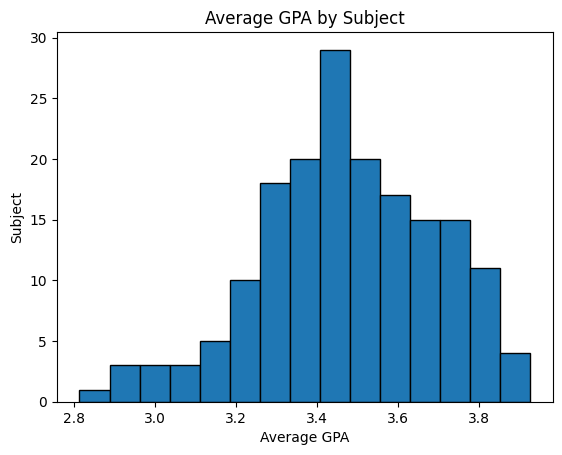

In [53]:
import matplotlib.pyplot as plt
df_subject["Average GPA"].plot.hist(bins=15, edgecolor = "black", xlabel = "Average GPA", ylabel = "Subject", title = "Average GPA by Subject")

### Puzzle 2.5: Your Major! 
We've done a lot of analysis on every course and every subject, but Data Science should also be personal to you!

Using your `df_subject`, isolate the row containing the `Subject` of **your Major**, storing in the variable `my_subject`:

(If you're undecided, you can pick any `Subject` you are interested in!)

In [54]:
my_subject = df_subject[df_subject["Subject"]== "ECON"]
my_subject

,Subject,Year,Term,YearTerm,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
57,ECON,7769515,WinterWinterWinterFallFallFallFallFallFallFall...,2024-wi2024-wi2024-wi2023-fa2023-fa2023-fa2023...,966233,Microeconomic PrinciplesMacroeconomic Principl...,ONLONLONLDISDISDISDISDISDISDISDISDISDISDISDISD...,22117,42231,21106,...,9521,4195,2668,3268,1561,4444,905,"DiIanni, IsaacVazquez, Jose JSchultz, ColleenC...",170864,3.192452


<hr style="color: #DD3403;">

# Part 3: GPA By Year
At this point, we've investigated the GPA Dataset as a whole and grouped by `Subject`. While our GPA Dataset contains **a lot** of course data, some of the listed courses are quite old: **dating back to 2010**!

One can question the changes to GPA **over time**. Some questions may include:
- Has GPA gone up, because classes became "easier"? 
- Has the GPA fallen because of stricter grading policies? 
- How was GPA impacted in 2019-2020 at the brunt of COVID? 

You will gain some insight into the answers to questions in this section of the lab. 

### Puzzle 3.1: Exploring Different Years

In the following cell, create a new DataFrame called `df_year` that has a single row for each year. In ``df_year``, each **letter grade column** should contain the **total number of students** receiving said grade in that `Year`. Make sure your DataFrame only contains numeric columns.

In [55]:
df_year = df.groupby("Year").agg("sum").reset_index()
df_year

,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
0,2010,FallFallFallFallFallFallFallFallFallFallFallFa...,2010-fa2010-fa2010-fa2010-fa2010-fa2010-fa2010...,AASAASAASAASAASAASAASAASAASAASABEABEABEABEABEA...,1493480,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISLCDDISDISDISLCDLECLECLECLCDLECL...,19355,77012,36814,...,15753,5812,2975,4438,1506,4511,1404,"Winkelmann, Marie TKwon, YaejoonKwon, YaejoonA...",271071,17983.181282
1,2011,FallFallFallFallFallFallFallFallFallFallFallFa...,2011-fa2011-fa2011-fa2011-fa2011-fa2011-fa2011...,AASAASAASAASAASAASAASAASAASABEABEABEABEABEACCY...,1435567,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISLCDLCDLECLECLECLECLECLCDL...,19569,75526,36462,...,15844,6243,2910,4513,1679,4751,1200,"Kinase-Leggett, ElizabethKinase-Leggett, Eliza...",269064,17216.397879
2,2012,FallFallFallFallFallFallFallFallFallFallFallFa...,2012-fa2012-fa2012-fa2012-fa2012-fa2012-fa2012...,AASAASAASAASAASAASAASABEABEABEABEABEABEABEABEA...,822949,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISLECLECLECLECLECLCDLECLECL...,11834,44738,20603,...,8221,3307,1690,2218,936,2681,626,"Carter, Regina SCarter, Regina SArai, SayuriDa...",151677,9532.509354
3,2013,FallFallFallFallFallFallFallFallFallFallFallFa...,2013-fa2013-fa2013-fa2013-fa2013-fa2013-fa2013...,AASAASAASAASAASAASAASABEABEABEABEABEABEACCYACC...,1468576,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISLCDLECLECLECLCDLECLECLCDLCDD...,22541,81114,37513,...,14875,6367,3103,4263,1851,4895,1072,"Arai, SayuriArai, SayuriDavis, Thomas EDavis, ...",276469,16764.437980
4,2014,FallFallFallFallFallFallFallFallFallFallFallFa...,2014-fa2014-fa2014-fa2014-fa2014-fa2014-fa2014...,AASAASAASAASAASAASAASABEABEABEABEABEABEABEACCY...,1440554,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISLCDLECLECLECLECLCDLECLECONLD...,25081,79289,36792,...,14802,6579,3252,4640,2073,5363,1292,"Thomas, Merin AThomas, Merin APeralta, Christi...",276736,16367.567458
5,2015,FallFallFallFallFallFallFallFallFallFallFallFa...,2015-fa2015-fa2015-fa2015-fa2015-fa2015-fa2015...,AASAASAASABEABEABEABEABEABEABEACCYACCYACCYACCY...,1516560,Intro Asian American StudiesIntro Asian Americ...,DISDISLCDLECLCDLECLECLECLECLECONLDISDISDISDISD...,29032,87101,39378,...,14891,6576,3550,4528,2050,5572,1317,"Peralta, Christine NLee, Sang SCacho, Lisa MGr...",295247,17371.653103
6,2016,FallFallFallFallFallFallFallFallFallFallFallFa...,2016-fa2016-fa2016-fa2016-fa2016-fa2016-fa2016...,AASAASAASAASAASAASAASAASABEABEABEABEABEABEACCY...,1452803,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISLCDLCDLCDLECLCDLCDLCDLECLCDONLL...,29094,85548,37962,...,14199,6114,3333,4271,1964,5785,1254,"Chung, Ga YoungChung, Ga YoungLee, Jean YLee, ...",284575,16591.965208
7,2017,FallFallFallFallFallFallFallFallFallFallFallFa...,2017-fa2017-fa2017-fa2017-fa2017-fa2017-fa2017...,AASAASAASAASAASAASAASAASAASABEABEABEABEABEABEA...,1513420,Intro Asian American StudiesIntro Asian Americ...,0,34941,92166,38295,...,14270,6130,3254,4600,2014,6151,1289,"Espiritu, Augusto FPaik, Angela NSharif, Lila ...",296862,17119.212533
8,2018,FallFallFallFallFallFallFallFallFallFallFallFa...,2018-fa2018-fa2018-fa2018-fa2018-fa2018-fa2018...,AASAASAASAASAASAASAASAASAASABEABEABEABEABEABEA...,1509424,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISLCDLCDLCDLCDLECLECLECLECLECLECL...,40112,98711,39621,...,13421,5949,3339,4350,2042,6253,1131,"Thomas, Merin ALee, Sang SKang, YoonjungThomas...",306113,17005.301120
9,2019,FallFallFallFallFallFallFallFallFallFallFallFa...,2019-fa2019-fa2019-fa2019-fa2019-fa2019-fa2019...,AASAASAASAASAASAASAASAASAASAASAASABEABEABEABEA...,1528969,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISDISLCDLCDLCDLECLCDLECLECL...,41642,104139,40875,...,13623,6117,3283,4434,2212,6914,1146,"Boonsripaisal, SimonUhall, Michael BKang, Yoo

### 🔬 Test Case Checkpoint 🔬

In [56]:
## == TEST CASE for Puzzle 3.1 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any errors, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
import math
assert( 'df_year' in vars() ), "Make sure your DataFrame grouped by Year is named 'df_year'." 
assert( (len(df_year.columns) == 24) | (len(df_year.columns) == 18)), "Make sure your DataFrame has the appropriate number of columns! Remember to use .reset_index()!"
assert( len(df_year) == 15 ), "Make sure you are grouping by 'Year'. There are 15 years in our original `df`, so the length of `df_year` should be 15."
assert( math.isclose(df_year.Students.mean(), 274749.3333333333) ), "Double-check that you are aggregating your df_year correctly."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Puzzle 3.2: Fixing our `Average GPA` Column Again
Some columns in `df_year` are incorrectly calculated given the way we've grouped the data.

Let's fix this by redefining the `Average GPA` column in our `df_year`.

The `Average GPA` column should contain the **weighted average GPA** of each `Year` by taking into account the **number of students** who received each letter grade in said `Year`. 

In [57]:
df_year["Average GPA"] = df_year.apply(calculateAverageGPA, axis =1)
df_year

,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,C,C-,D+,D,D-,F,W,Primary Instructor,Students,Average GPA
0,2010,FallFallFallFallFallFallFallFallFallFallFallFa...,2010-fa2010-fa2010-fa2010-fa2010-fa2010-fa2010...,AASAASAASAASAASAASAASAASAASAASABEABEABEABEABEA...,1493480,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISLCDDISDISDISLCDLECLECLECLCDLECL...,19355,77012,36814,...,15753,5812,2975,4438,1506,4511,1404,"Winkelmann, Marie TKwon, YaejoonKwon, YaejoonA...",271071,3.233537
1,2011,FallFallFallFallFallFallFallFallFallFallFallFa...,2011-fa2011-fa2011-fa2011-fa2011-fa2011-fa2011...,AASAASAASAASAASAASAASAASAASABEABEABEABEABEACCY...,1435567,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISLCDLCDLECLECLECLECLECLCDL...,19569,75526,36462,...,15844,6243,2910,4513,1679,4751,1200,"Kinase-Leggett, ElizabethKinase-Leggett, Eliza...",269064,3.224523
2,2012,FallFallFallFallFallFallFallFallFallFallFallFa...,2012-fa2012-fa2012-fa2012-fa2012-fa2012-fa2012...,AASAASAASAASAASAASAASABEABEABEABEABEABEABEABEA...,822949,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISLECLECLECLECLECLCDLECLECL...,11834,44738,20603,...,8221,3307,1690,2218,936,2681,626,"Carter, Regina SCarter, Regina SArai, SayuriDa...",151677,3.253189
3,2013,FallFallFallFallFallFallFallFallFallFallFallFa...,2013-fa2013-fa2013-fa2013-fa2013-fa2013-fa2013...,AASAASAASAASAASAASAASABEABEABEABEABEABEACCYACC...,1468576,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISLCDLECLECLECLCDLECLECLCDLCDD...,22541,81114,37513,...,14875,6367,3103,4263,1851,4895,1072,"Arai, SayuriArai, SayuriDavis, Thomas EDavis, ...",276469,3.250664
4,2014,FallFallFallFallFallFallFallFallFallFallFallFa...,2014-fa2014-fa2014-fa2014-fa2014-fa2014-fa2014...,AASAASAASAASAASAASAASABEABEABEABEABEABEABEACCY...,1440554,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISLCDLECLECLECLECLCDLECLECONLD...,25081,79289,36792,...,14802,6579,3252,4640,2073,5363,1292,"Thomas, Merin AThomas, Merin APeralta, Christi...",276736,3.239539
5,2015,FallFallFallFallFallFallFallFallFallFallFallFa...,2015-fa2015-fa2015-fa2015-fa2015-fa2015-fa2015...,AASAASAASABEABEABEABEABEABEABEACCYACCYACCYACCY...,1516560,Intro Asian American StudiesIntro Asian Americ...,DISDISLCDLECLCDLECLECLECLECLECONLDISDISDISDISD...,29032,87101,39378,...,14891,6576,3550,4528,2050,5572,1317,"Peralta, Christine NLee, Sang SCacho, Lisa MGr...",295247,3.266565
6,2016,FallFallFallFallFallFallFallFallFallFallFallFa...,2016-fa2016-fa2016-fa2016-fa2016-fa2016-fa2016...,AASAASAASAASAASAASAASAASABEABEABEABEABEABEACCY...,1452803,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISLCDLCDLCDLECLCDLCDLCDLECLCDONLL...,29094,85548,37962,...,14199,6114,3333,4271,1964,5785,1254,"Chung, Ga YoungChung, Ga YoungLee, Jean YLee, ...",284575,3.275508
7,2017,FallFallFallFallFallFallFallFallFallFallFallFa...,2017-fa2017-fa2017-fa2017-fa2017-fa2017-fa2017...,AASAASAASAASAASAASAASAASAASABEABEABEABEABEABEA...,1513420,Intro Asian American StudiesIntro Asian Americ...,0,34941,92166,38295,...,14270,6130,3254,4600,2014,6151,1289,"Espiritu, Augusto FPaik, Angela NSharif, Lila ...",296862,3.301601
8,2018,FallFallFallFallFallFallFallFallFallFallFallFa...,2018-fa2018-fa2018-fa2018-fa2018-fa2018-fa2018...,AASAASAASAASAASAASAASAASAASABEABEABEABEABEABEA...,1509424,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISLCDLCDLCDLCDLECLECLECLECLECLECL...,40112,98711,39621,...,13421,5949,3339,4350,2042,6253,1131,"Thomas, Merin ALee, Sang SKang, YoonjungThomas...",306113,3.337883
9,2019,FallFallFallFallFallFallFallFallFallFallFallFa...,2019-fa2019-fa2019-fa2019-fa2019-fa2019-fa2019...,AASAASAASAASAASAASAASAASAASAASAASABEABEABEABEA...,1528969,Intro Asian American StudiesIntro Asian Americ...,DISDISDISDISDISDISDISDISLCDLCDLCDLECLCDLECLECL...,41642,104139,40875,...,13623,6117,3283,4434,2212,6914,1146,"Boonsripaisal, SimonUhall, Michael BKang, Yoon...",319344,3.339275


### 🔬 Test Case Checkpoint 🔬

In [58]:
## == TEST CASE for Puzzle 3.2 ==
# - This read-only cell contains test cases for your previous cell.
# - If this cell runs without any errors, you PASSED all test cases!
# - If this cell results in any errors, check your previous cell, make changes, and RE-RUN your code and then this cell.
import math
assert( len(df_year) == 15 ), "You shouldn't be changing the length of `df_year` when recomputing Average GPA."
assert( "Average GPA" in df_year.columns), "Make sure your column is still named 'Average GPA'."
assert( math.isclose(df_year['Average GPA'].mean(), 3.3497684856756313) ), "Your calculation of the Average GPA by Year is incorrect."

## == SUCCESS MESSAGE ==
# You will only see this message (with the emoji showing) if you passed all test cases:
tada = "\N{PARTY POPPER}"
print(f"{tada} All tests passed! {tada}")

🎉 All tests passed! 🎉


### Puzzle 3.3: Visualizing GPA over Time
We now have the data of the `Average GPA` across the University over time in years. Using this data, we can generate yet another visualization built-in to Pandas to visualize this data: a **line plot**! 

In the cell below, plot the **average GPA over time** using `df_year`. Make sure your line plot looks nice and has an appropriate x-axis label, y-axis label, and title!

In [59]:
from matplotlib import style
style.use('dark_background')

<Axes: title={'center': 'Average GPA by Year'}, xlabel='Year'>

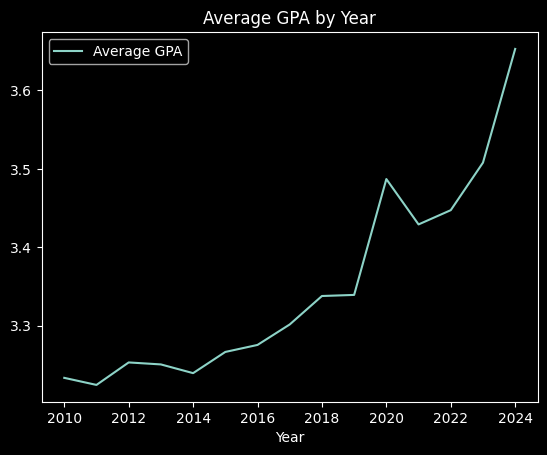

In [61]:
df_year.plot(x = "Year", y = "Average GPA", title = "Average GPA by Year")

***Side Note***: If you're using **Visual Studio Code** on **dark mode**, you may not be able to see the **axes** and **axes labels** of the graph. 

**Only if** this is the case, please **copy and run** the following **two lines** of code in a cell:

---
```py
from matplotlib import style
style.use('dark_background')
```
---

And then **re-run your plotting code** above. 

### Analysis: GPA Dataset Interpretations

**Question 1**: Based on all of the analysis you did in Parts 1 and 2, what is the most interesting thing you learned
**Question 2**: Note a few observations you have about the changes to `Average GPA` at Illinois over time. Is there an overall trend? What events could have spiked increases to the Average GPA? Explain your answer in detail!

1. The most intersting thing that I learned was how high the average GPA for business subjects are. Even though they have nearly 15000 students taking business classes to keep that amount of students at an average GPA of 3.86.
2. What I noticed about the Average GPA at Illinois over time was that it has been increasing significantly since 2019. With a spike in 2020 then a drop, and with another spike right now. I think the cause of the first spike is covid-19 where everybody went to remote learning. Then the cause of the current spike is due to the use of AI.

<hr style="color: #DD3403;">

# Submission

You're almost done!  All you need to do is to commit your lab to GitHub:

1.  ⚠️ **Make certain to save your work.** ⚠️ To do this, go to **File => Save All**

2.  After you have saved, exit this notebook and follow the Canvas instructions to commit this lab to your Git repository!

3. Your TA will grade your submission and provide you feedback after the lab is due. :)